# CRC Single Cell Dataset Exploration

This notebook is used to explore and compare candidate colorectal cancer single cell datasets before selecting the dataset and analysis strategy for the project.

## 1. Setup

In [16]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/cfs/earth/scratch/suereser/crc_singlecell")
DATA_DIR = PROJECT_DIR / "data"

GSE108989_DIR = DATA_DIR / "2018_GSE108989"
GSE146771_DIR = DATA_DIR / "2020_GSE146771"

## 2. Helper Functions

In [17]:
def list_files(folder):
    """
    List all files in a folder together with their size in MB.
    """
    for file in sorted(folder.iterdir()):
        if file.is_file():
            size_mb = file.stat().st_size / (1024 ** 2)
            print(f"{file.name} | {size_mb:.2f} MB")

In [18]:
def inspect_table(path, sep="\t", nrows=5):
    """
    Load only the first rows of a compressed or uncompressed table
    to inspect its structure without loading the full dataset.
    """
    df = pd.read_csv(
        path,
        sep=sep,
        nrows=nrows,
        compression="infer"
    )

    print(f"File: {path.name}")
    print(f"Preview shape: {df.shape}")
    print(f"Number of columns: {len(df.columns)}")
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst rows:")
    display(df.head())

    return df

In [19]:
def inspect_whitespace_table(path, nrows=5):
    """
    Inspect tables that are separated by whitespace rather than tabs.
    """
    df = pd.read_csv(
        path,
        sep=r"\s+",
        nrows=nrows,
        compression="infer"
    )

    print(f"File: {path.name}")
    print(f"Preview shape: {df.shape}")
    print(f"Number of columns: {len(df.columns)}")

    print("\nFirst column names:")
    print(df.columns[:10].tolist())

    print("\nFirst rows:")
    display(df.iloc[:, :10])

    return df

## 3. GSE108989, Zhang 2018

### 3.1 Available files

In [20]:
list_files(GSE108989_DIR)

GSE108989_CRC.TCell.S10805.norm.centered.txt.gz | 368.54 MB
GSE108989_CRC.TCell.S11138.TPM.txt.gz | 351.58 MB
GSE108989_CRC.TCell.S11138.count.txt.gz | 69.67 MB
GSE108989_CRC.bulk.S12.TPM.tab.gz | 2.12 MB
GSE108989_CRC.bulk.S12.count.tab.gz | 0.56 MB
GSE108989_CRC.bulk.exome.mutation.tab.gz | 0.13 MB
GSE108989_cell_metadata_full.htm | 0.42 MB


### 3.2 Inspect GSE108989 files

In [21]:
gse108989_mutation = inspect_table(
    GSE108989_DIR / "GSE108989_CRC.bulk.exome.mutation.tab.gz"
)

File: GSE108989_CRC.bulk.exome.mutation.tab.gz
Preview shape: (5, 76)
Number of columns: 76

Columns:
['patient', 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'QSS', 'TQSS', 'NT', 'QSS_NT', 'TQSS_NT', 'SGT', 'SOMATIC', 'NORMAL_FREQ', 'TUMOR_FREQ', 'Func', 'Gene', 'GeneDetail', 'ExonicFunc', 'AAChange', 'cytoband', 'genomicSuperDups', 'phastConsElements46way', 'evofold', 'wgRna', 'targetScanS', 'tfbsConsSites', 'esp6500siv2_all', '1000g2014oct_all', '1000g2014oct_afr', '1000g2014oct_eas', '1000g2014oct_eur', 'avsnp142', 'SIFT_score', 'SIFT_pred', 'Polyphen2_HDIV_score', 'Polyphen2_HDIV_pred', 'Polyphen2_HVAR_score', 'Polyphen2_HVAR_pred', 'LRT_score', 'LRT_pred', 'MutationTaster_score', 'MutationTaster_pred', 'MutationAssessor_score', 'MutationAssessor_pred', 'FATHMM_score', 'FATHMM_pred', 'RadialSVM_score', 'RadialSVM_pred', 'LR_score', 'LR_pred', 'VEST3_score', 'CADD_raw', 'CADD_phred', 'GERP++_RS', 'phyloP46way_placental', 'phyloP100way_vertebrate', 'SiPhy_29way_logOdds', 'g

,patient,CHROM,POS,ID,REF,ALT,QUAL,FILTER,QSS,TQSS,...,OMIM_DAVID,CancerGeneCensus,BertVogelstein125,Predisposition,DriverCNA,Rearrangement,GO_BP,GO_CC,GO_MF,REACTOME_PATHWAY
0,P1207T,1,1888083,.,G,A,.,PASS,304,-,...,.,.,.,.,.,.,.,.,.,.
1,P1207T,1,15650938,.,G,T,.,PASS,105,-,...,.,.,.,.,.,.,.,.,.,.
2,P1207T,1,53363188,.,T,A,.,PASS,46,-,...,.,.,.,.,.,.,GO:0055114~oxidation-reduction process;GO:0019...,GO:0005739~mitochondrion,GO:0016835~carbon-oxygen lyase activity;GO:001...,.
3,P1207T,1,93620290,.,C,T,.,PASS,26,-,...,.,.,.,.,.,.,GO:0033036~macromolecule localization;GO:00901...,GO:0005783~endoplasmic reticulum;GO:0005793~en...,.,R-HSA-3238698:R-HSA-3238698
4,P1207T,1,103548536,.,A,G,.,PASS,24,-,...,228520~Fibrochondrogenesis 1;603932~Lumbar dis...,.,.,.,.,.,GO:0042471~ear morphogenesis;GO:0001501~skelet...,GO:0005576~extracellular region;GO:0005783~end...,GO:0005198~structural molecule activity;GO:006...,R-HSA-1650814:R-HSA-1650814;R-HSA-3000171:R-HS...


In [22]:
gse108989_bulk_count = inspect_table(
    GSE108989_DIR / "GSE108989_CRC.bulk.S12.count.tab.gz"
)

File: GSE108989_CRC.bulk.S12.count.tab.gz
Preview shape: (5, 14)
Number of columns: 14

Columns:
['geneID', 'symbol', 'P0123', 'P0215', 'P0309', 'P0411', 'P0413', 'P0701', 'P0825', 'P0909', 'P1012', 'P1207', 'P1212', 'P1228']

First rows:


,geneID,symbol,P0123,P0215,P0309,P0411,P0413,P0701,P0825,P0909,P1012,P1207,P1212,P1228
0,1,A1BG,181,186,56,144,145,34,74,94,166,53,126,143
1,10,NAT2,0,51,268,208,2,930,1,590,1,18,0,3
2,100,ADA,342,630,89,206,325,317,213,562,928,61,200,469
3,1000,CDH2,54,623,142,86,635,9,28,102,296,68,70,199
4,10000,AKT3,472,925,805,1038,2886,211,679,828,1938,415,868,1504


In [23]:
gse108989_bulk_tpm = inspect_table(
    GSE108989_DIR / "GSE108989_CRC.bulk.S12.TPM.tab.gz"
)

File: GSE108989_CRC.bulk.S12.TPM.tab.gz
Preview shape: (5, 14)
Number of columns: 14

Columns:
['geneID', 'symbol', 'P0123', 'P0215', 'P0309', 'P0411', 'P0413', 'P0701', 'P0825', 'P0909', 'P1012', 'P1207', 'P1212', 'P1228']

First rows:


,geneID,symbol,P0123,P0215,P0309,P0411,P0413,P0701,P0825,P0909,P1012,P1207,P1212,P1228
0,1,A1BG,4.456907,2.918406,1.420063,3.539366,3.792435,0.781577,2.138246,2.214791,2.467034,1.751027,4.756861,3.996514
1,10,NAT2,0.000000,2.446802,20.780220,15.632275,0.159947,65.368957,0.088353,42.506240,0.045443,1.818383,0.000000,0.256367
2,100,ADA,22.136244,25.983410,5.932426,13.309235,22.343767,19.154679,16.178135,34.806793,36.252496,5.297484,19.847363,34.454109
3,1000,CDH2,1.197103,8.800422,3.241832,1.903024,14.952252,0.186259,0.728395,2.163654,3.960423,2.022594,2.379199,5.007041
4,10000,AKT3,6.375634,7.961609,11.198034,13.995447,41.406917,2.660735,10.762723,10.701917,15.799642,7.521275,17.976125,23.057890


### 3.3 Cell metadata

In [24]:
from bs4 import BeautifulSoup
from io import StringIO

html_path = GSE108989_DIR / "GSE108989_cell_metadata_full.htm"

with open(html_path, "r", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "html.parser")

text = soup.find("pre").get_text()

gse108989_metadata = pd.read_csv(
    StringIO(text),
    sep="\t",
    comment="#"
)

print("Shape:", gse108989_metadata.shape)
print("Columns:", gse108989_metadata.columns.tolist())

display(gse108989_metadata.head())
gse108989_metadata.columns = gse108989_metadata.columns.str.strip()
print(gse108989_metadata.columns.tolist())

Shape: (11138, 4)
Columns: ['UniqueCell_ID ', 'Patient_ID', 'majorCluster', 'sampleType']


,UniqueCell_ID,Patient_ID,majorCluster,sampleType
0,NTH5-20180123,P0123,CD4_C01-CCR7,NTH
1,NTH64-20180123,P0123,CD4_C01-CCR7,NTH
2,NTR57-20180123,P0123,CD4_C01-CCR7,NTR
3,PP7-100-20180123,P0123,CD4_C01-CCR7,PP7
4,PP7-106-20180123,P0123,CD4_C01-CCR7,PP7


['UniqueCell_ID', 'Patient_ID', 'majorCluster', 'sampleType']


In [25]:
gse108989_count_preview = pd.read_csv(
    GSE108989_DIR / "GSE108989_CRC.TCell.S11138.count.txt.gz",
    sep="\t",
    nrows=5,
    compression="infer"
)

### 3.3.1 Metadata overview

In [26]:
print("Number of cells:", gse108989_metadata.shape[0])
print("Number of patients:", gse108989_metadata["Patient_ID"].nunique())
print("Number of clusters:", gse108989_metadata["majorCluster"].nunique())
print("Number of sample types:", gse108989_metadata["sampleType"].nunique())

Number of cells: 11138
Number of patients: 12
Number of clusters: 29
Number of sample types: 15


In [27]:
print("Cells per patient:")
display(gse108989_metadata["Patient_ID"].value_counts())

Cells per patient:


Patient_ID
P0825    1253
P0123    1238
P1228    1210
P1212    1164
P0909    1105
P1012    1065
P0701     852
P0413     765
P0411     764
P0309     758
P0215     754
P1207     210
Name: count, dtype: int64

In [28]:
print("Major clusters:")
display(gse108989_metadata["majorCluster"].value_counts())

Major clusters:


majorCluster
CD4_C12-CTLA4      1319
diverse.DN         1252
diverse.other       949
CD8_C04-GZMK        840
CD8_C07-LAYN        831
CD8_C03-CX3CR1      773
CD4_C05-CXCR6       639
CD4_C02-ANXA1       509
CD4_C01-CCR7        472
CD8_C05-CD6         431
CD4_C10-FOXP3       365
CD8_C06-CD160       363
filtered            333
CD4_C04-TCF7        331
CD4_C09-CXCL13      272
CD4_C08-IL23R       229
CD4_C06-CXCR5       216
CD4_C07-GZMK        204
CD4_C11-IL10        176
CD4_C03-GNLY        170
CD8_C01-LEF1        164
CD8_C02-GPR183      155
CD8_C08-SLC4A10      71
diverse.DP           40
MAIT.other           16
MAIT.CD4             11
MAIT.DN               4
iNKT.CD4              2
iNKT.DN               1
Name: count, dtype: int64

In [29]:
print("Sample types:")
display(gse108989_metadata["sampleType"].value_counts())

Sample types:


sampleType
TTC    1806
TTR    1435
TTH    1370
PTC    1132
NTC    1072
PTH     997
NTH     953
PTR     912
NTR     406
TTY     304
TP7     234
PTY     164
PP7     147
NTY     140
NP7      66
Name: count, dtype: int64

In [30]:
count_cells = set(gse108989_count_preview.columns[2:])
metadata_cells = set(gse108989_metadata["UniqueCell_ID"])

print("Cells in count preview:", len(count_cells))
print("Metadata cells:", len(metadata_cells))
print("Matching cells:", len(count_cells & metadata_cells))

Cells in count preview: 11138
Metadata cells: 11138
Matching cells: 11138


**Summary:**  
GSE108989 contains 11,138 single cells from 12 patients, divided into 29 major T cell clusters and 15 sample types. All 11,138 cell IDs in the metadata match the cell IDs in the count matrix, confirming that the metadata can be directly linked to the expression data.

### 3.4 Single cell expression matrices

In [31]:
gse108989_count_preview = inspect_table(
    GSE108989_DIR / "GSE108989_CRC.TCell.S11138.count.txt.gz",
    nrows=5
)

File: GSE108989_CRC.TCell.S11138.count.txt.gz
Preview shape: (5, 11140)
Number of columns: 11140

Columns:
['geneID', 'symbol', 'NP710-20180123', 'NP711-20180123', 'NP71-20180123', 'NP712-20180123', 'NP713-20180123', 'NP714-20180123', 'NP716-20180123', 'NP718-20180123', 'NP719-20180123', 'NP720-20180123', 'NP721-20180123', 'NP72-20180123', 'NP724-20180123', 'NP727-20180123', 'NP728-20180123', 'NP730-20180123', 'NP731-20180123', 'NP73-20180123', 'NP732-20180123', 'NP734-20180123', 'NP735-20180123', 'NP737-20180123', 'NP738-20180123', 'NP739-20180123', 'NP740-20180123', 'NP74-20180123', 'NP742-20180123', 'NP743-20180123', 'NP744-20180123', 'NP746-20180123', 'NP747-20180123', 'NP749-20180123', 'NP750-20180123', 'NP75-20180123', 'NP754-20180123', 'NP755-20180123', 'NP756-20180123', 'NP762-20180123', 'NP763-20180123', 'NP764-20180123', 'NP766-20180123', 'NP768-20180123', 'NP769-20180123', 'NP770-20180123', 'NP771-20180123', 'NP77-20180123', 'NP772-20180123', 'NP776-20180123', 'NP777-2018012

,geneID,symbol,NP710-20180123,NP711-20180123,NP71-20180123,NP712-20180123,NP713-20180123,NP714-20180123,NP716-20180123,NP718-20180123,...,PTC87-20161228,PTC89-20161228,PTC90-20161228,PTC91-20161228,PTC9-20161228,PTC92-20161228,PTC93-20161228,PTC94-20161228,PTC95-20161228,PTC96-20161228
0,1,A1BG,0,0,27,0,23,0,0,0,...,0,0,0,0,11,8,0,14,0,0
1,10,NAT2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,100,ADA,0,0,0,0,0,42,0,0,...,0,53,0,0,0,498,2,0,183,0
3,1000,CDH2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,10000,AKT3,0,0,0,0,0,0,0,0,...,1,0,0,0,353,0,4,0,0,0


In [32]:
gse108989_tpm_preview = inspect_table(
    GSE108989_DIR / "GSE108989_CRC.TCell.S11138.TPM.txt.gz",
    nrows=5
)

File: GSE108989_CRC.TCell.S11138.TPM.txt.gz
Preview shape: (5, 11140)
Number of columns: 11140

Columns:
['geneID', 'symbol', 'NP710-20180123', 'NP711-20180123', 'NP71-20180123', 'NP712-20180123', 'NP713-20180123', 'NP714-20180123', 'NP716-20180123', 'NP718-20180123', 'NP719-20180123', 'NP720-20180123', 'NP721-20180123', 'NP72-20180123', 'NP724-20180123', 'NP727-20180123', 'NP728-20180123', 'NP730-20180123', 'NP731-20180123', 'NP73-20180123', 'NP732-20180123', 'NP734-20180123', 'NP735-20180123', 'NP737-20180123', 'NP738-20180123', 'NP739-20180123', 'NP740-20180123', 'NP74-20180123', 'NP742-20180123', 'NP743-20180123', 'NP744-20180123', 'NP746-20180123', 'NP747-20180123', 'NP749-20180123', 'NP750-20180123', 'NP75-20180123', 'NP754-20180123', 'NP755-20180123', 'NP756-20180123', 'NP762-20180123', 'NP763-20180123', 'NP764-20180123', 'NP766-20180123', 'NP768-20180123', 'NP769-20180123', 'NP770-20180123', 'NP771-20180123', 'NP77-20180123', 'NP772-20180123', 'NP776-20180123', 'NP777-20180123'

,geneID,symbol,NP710-20180123,NP711-20180123,NP71-20180123,NP712-20180123,NP713-20180123,NP714-20180123,NP716-20180123,NP718-20180123,...,PTC87-20161228,PTC89-20161228,PTC90-20161228,PTC91-20161228,PTC9-20161228,PTC92-20161228,PTC93-20161228,PTC94-20161228,PTC95-20161228,PTC96-20161228
0,1,A1BG,0,0,48.191757,0,33.522948,0.000000,0,0,...,0.000000,0.000000,0,0,9.164084,7.891868,0.000000,15.595108,0.00000,0
1,10,NAT2,0,0,0.000000,0,0.000000,0.000000,0,0,...,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,0.00000,0
2,100,ADA,0,0,0.000000,0,0.000000,159.547818,0,0,...,0.000000,166.988388,0,0,0.000000,1291.344327,6.030960,0.000000,627.51695,0
3,1000,CDH2,0,0,0.000000,0,0.000000,0.000000,0,0,...,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,0.00000,0
4,10000,AKT3,0,0,0.000000,0,0.000000,0.000000,0,0,...,0.642826,0.000000,0,0,161.323445,0.000000,2.517213,0.000000,0.00000,0


In [33]:
gse108989_norm_preview = inspect_table(
    GSE108989_DIR / "GSE108989_CRC.TCell.S10805.norm.centered.txt.gz",
    nrows=5
)

File: GSE108989_CRC.TCell.S10805.norm.centered.txt.gz
Preview shape: (5, 10807)
Number of columns: 10807

Columns:
['geneID', 'geneSymbol', 'NP710-20180123', 'NP711-20180123', 'NP71-20180123', 'NP712-20180123', 'NP713-20180123', 'NP714-20180123', 'NP718-20180123', 'NP720-20180123', 'NP721-20180123', 'NP72-20180123', 'NP724-20180123', 'NP727-20180123', 'NP728-20180123', 'NP731-20180123', 'NP73-20180123', 'NP732-20180123', 'NP734-20180123', 'NP735-20180123', 'NP737-20180123', 'NP738-20180123', 'NP739-20180123', 'NP740-20180123', 'NP74-20180123', 'NP742-20180123', 'NP743-20180123', 'NP744-20180123', 'NP746-20180123', 'NP747-20180123', 'NP750-20180123', 'NP75-20180123', 'NP754-20180123', 'NP755-20180123', 'NP762-20180123', 'NP763-20180123', 'NP764-20180123', 'NP768-20180123', 'NP769-20180123', 'NP770-20180123', 'NP77-20180123', 'NP772-20180123', 'NP776-20180123', 'NP777-20180123', 'NP779-20180123', 'NP780-20180123', 'NP78-20180123', 'NP782-20180123', 'NP783-20180123', 'NP785-20180123', 'NP

,geneID,geneSymbol,NP710-20180123,NP711-20180123,NP71-20180123,NP712-20180123,NP713-20180123,NP714-20180123,NP718-20180123,NP720-20180123,...,PTC87-20161228,PTC89-20161228,PTC90-20161228,PTC91-20161228,PTC9-20161228,PTC92-20161228,PTC93-20161228,PTC94-20161228,PTC95-20161228,PTC96-20161228
0,1,A1BG,-0.515412,-0.515412,5.518178,-0.515412,4.825216,-0.515412,-0.515412,-0.515412,...,-0.710540,-0.710540,-0.710540,-0.710540,2.482191,2.511708,-0.710540,3.289508,-0.710540,-0.710540
1,100,ADA,-1.862244,-1.862244,-1.862244,-1.862244,-1.862244,4.373298,-1.862244,-1.862244,...,-1.291556,5.078320,-1.291556,-1.291556,-1.291556,7.729957,0.494275,-1.291556,6.638120,-1.291556
2,10000,AKT3,-0.458035,-0.458035,-0.458035,-0.458035,-0.458035,-0.458035,-0.458035,-0.458035,...,0.097423,-0.879971,-0.879971,-0.879971,7.155262,-0.879971,1.679848,-0.879971,-0.879971,-0.879971
3,100009676,ZBTB11-AS1,-0.663205,-0.663205,-0.663205,2.583524,-0.663205,2.875517,-0.663205,-0.663205,...,-0.724589,2.397731,-0.724589,-0.724589,1.903522,-0.724589,-0.724589,-0.724589,1.144799,-0.724589
4,10001,MED6,-1.040214,-1.040214,7.163710,-1.040214,-1.040214,-1.040214,0.494472,-1.040214,...,-2.034341,-2.034341,-2.034341,6.226741,5.757552,-1.004676,-0.881129,5.540439,-2.034341,5.084832


## 4. GSE146771, 2020

### 4.1 Available files

In [34]:
list_files(GSE146771_DIR)

GSE146771_CRC.Leukocyte.10x.Metadata.txt.gz | 2.98 MB
GSE146771_CRC.Leukocyte.10x.TPM.txt.gz | 433.52 MB
GSE146771_CRC.Leukocyte.Smart-seq2.Metadata.txt.gz | 0.78 MB
GSE146771_CRC.Leukocyte.Smart-seq2.TPM.txt.gz | 388.21 MB


### 4.2 Smart-seq2 metadata

In [35]:
smartseq_metadata = inspect_table(
    GSE146771_DIR / "GSE146771_CRC.Leukocyte.Smart-seq2.Metadata.txt.gz"
)

File: GSE146771_CRC.Leukocyte.Smart-seq2.Metadata.txt.gz
Preview shape: (5, 23)
Number of columns: 23

Columns:
['Barcode', 'CellName', 'Sample', 'Tissue', 'Platform', 'raw.nUMI', 'raw.nGene', 'filter.nUMI', 'filter.nGene', 'ribo.per', 'raw.nCD', 'raw.nTF', 'raw.nCyt', 'raw.nLR', 'Global_Cluster', 'Sub_Cluster', 'Sub_ClusterID', 'Global_tSNE_1', 'Global_tSNE_2', 'Sub_tSNE_1', 'Sub_tSNE_2', 'integrated.Global_tSNE_1', 'integrated.Global_tSNE_2']

First rows:


,Barcode,CellName,Sample,Tissue,Platform,raw.nUMI,raw.nGene,filter.nUMI,filter.nGene,ribo.per,...,raw.nLR,Global_Cluster,Sub_Cluster,Sub_ClusterID,Global_tSNE_1,Global_tSNE_2,Sub_tSNE_1,Sub_tSNE_2,integrated.Global_tSNE_1,integrated.Global_tSNE_2
0,TCD45n-101-20180104,N_T_P0104_00001,P0104,T,Smart-seq2,361999.1204,1391,149874.8968,1245,0.003445,...,72,Epithelial cell,hE06_UnIdent,hE06,-14.765383,34.427211,8.846055,12.177889,29.262951,-17.992092
1,TCD45n-10-20180104,N_T_P0104_00002,P0104,T,Smart-seq2,528956.2216,3498,379406.2269,3081,0.001964,...,144,Epithelial cell,hE02_Enterocyte-GUCA2B,hE02,2.106840,32.018599,-5.121409,19.143110,31.023631,-21.388089
2,TCD45n-105-20180104,N_T_P0104_00003,P0104,T,Smart-seq2,393885.6709,1831,153265.5659,1602,0.006838,...,97,Epithelial cell,hE02_Enterocyte-GUCA2B,hE02,-11.123330,30.973032,1.468617,17.171193,30.224962,-19.145937
3,TCD45n-107-20180104,N_T_P0104_00004,P0104,T,Smart-seq2,633193.9909,1753,426985.2652,1559,0.000738,...,85,Epithelial cell,hE02_Enterocyte-GUCA2B,hE02,-14.009335,31.040385,-0.626185,16.515109,30.202433,-19.185950
4,TCD45n-108-20180104,N_T_P0104_00005,P0104,T,Smart-seq2,511993.8998,5127,328379.3209,4369,0.025553,...,212,Epithelial cell,hE03_Goblet-SPINK4,hE03,-1.466837,36.112234,1.219953,4.973067,26.183327,-15.175587


In [45]:
smartseq_meta = pd.read_csv(
    GSE146771_DIR / "GSE146771_CRC.Leukocyte.Smart-seq2.Metadata.txt.gz",
    sep="\t"
)

print("Number of cells:", smartseq_meta.shape[0])
print("Number of samples:", smartseq_meta["Sample"].nunique())
print("Number of global cell types:", smartseq_meta["Global_Cluster"].nunique())
print("Number of subclusters:", smartseq_meta["Sub_Cluster"].nunique())

Number of cells: 10468
Number of samples: 10
Number of global cell types: 8
Number of subclusters: 48


In [46]:
print("Global cell types:")
display(smartseq_meta["Global_Cluster"].value_counts())

Global cell types:


Global_Cluster
CD4 T cell         3143
CD8 T cell         2405
Myeloid cell       1709
B cell              991
ILC                 953
Epithelial cell     860
Malignant cell      269
Fibroblast          138
Name: count, dtype: int64

In [47]:
print("Tissue types:")
display(smartseq_meta["Tissue"].value_counts())

Tissue types:


Tissue
T    5220
P    2839
N    2409
Name: count, dtype: int64

### 4.2.1 Dataset overview

In [36]:
smartseq_meta = pd.read_csv(
    GSE146771_DIR / "GSE146771_CRC.Leukocyte.Smart-seq2.Metadata.txt.gz",
    sep="\t"
)

print("Number of cells:", smartseq_meta.shape[0])
print("Number of metadata columns:", smartseq_meta.shape[1])
print("Number of samples:", smartseq_meta["Sample"].nunique())

Number of cells: 10468
Number of metadata columns: 23
Number of samples: 10


In [37]:
print("Tissue distribution:")
display(smartseq_meta["Tissue"].value_counts())

Tissue distribution:


Tissue
T    5220
P    2839
N    2409
Name: count, dtype: int64

In [38]:
print("Global cell types:")
display(smartseq_meta["Global_Cluster"].value_counts())

Global cell types:


Global_Cluster
CD4 T cell         3143
CD8 T cell         2405
Myeloid cell       1709
B cell              991
ILC                 953
Epithelial cell     860
Malignant cell      269
Fibroblast          138
Name: count, dtype: int64

<Axes: title={'center': 'GSE146771 Smart-seq2: Cell type distribution'}, ylabel='Global_Cluster'>

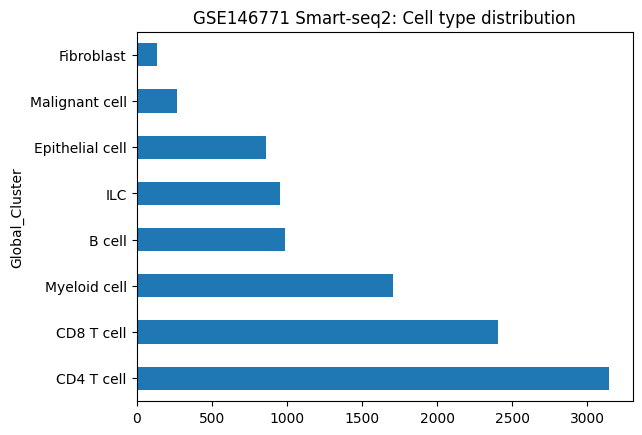

In [53]:
smartseq_meta["Global_Cluster"].value_counts().plot(
    kind="barh",
    title="GSE146771 Smart-seq2: Cell type distribution"
)

In [39]:
print("Number of subclusters:", smartseq_meta["Sub_Cluster"].nunique())

display(
    smartseq_meta["Sub_Cluster"]
    .value_counts()
    .head(20)
)

Number of subclusters: 48


Sub_Cluster
hT11_CD4-CTLA4      696
hT14_CD8-CX3CR1     579
hT15_CD8-GZMK       570
hB02_GALTB-IgA      563
hM05_Mono-CD14      544
hI01_NK-CD16        486
hT16_CD8-CD6        434
hT18_CD8-LAYN       407
hT05_CD4-CXCR6      407
hT01_CD4-CCR7       361
hT04_CD4-TCF7       332
hT02_CD4-ANXA1      325
hM12_TAM-C1QC       293
hT09_CD4-CXCL13     282
hT17_CD8-CD160      277
hM01_Mast-TPSAB1    255
hE04_Goblet-REG4    226
hI02_NK-GZMK        225
hM06_Mono-CD16      220
hE06_UnIdent        213
Name: count, dtype: int64

In [49]:
print("Cells per sample:")
display(smartseq_meta["Sample"].value_counts())

Cells per sample:


Sample
P0825    2145
P1228    1639
P1212    1465
P0413    1369
P0309    1187
P0411     926
P0728     786
P0720     495
P0305     267
P0104     189
Name: count, dtype: int64

In [50]:
print("Cell types by tissue:")
display(pd.crosstab(
    smartseq_meta["Global_Cluster"],
    smartseq_meta["Tissue"]
))

Cell types by tissue:


Tissue,N,P,T
Global_Cluster,,,
B cell,562,87,342
CD4 T cell,793,964,1386
CD8 T cell,720,628,1057
Epithelial cell,133,5,722
Fibroblast,5,0,133
ILC,96,455,402
Malignant cell,2,0,267
Myeloid cell,98,700,911


### 4.3 10x metadata

In [42]:
tenx_metadata = inspect_table(
    GSE146771_DIR / "GSE146771_CRC.Leukocyte.10x.Metadata.txt.gz"
)

File: GSE146771_CRC.Leukocyte.10x.Metadata.txt.gz
Preview shape: (5, 23)
Number of columns: 23

Columns:
['Sample_BarcodeID', 'CellName', 'Sample', 'Tissue', 'Platform', 'raw.nUMI', 'raw.nGene', 'filter.nUMI', 'filter.nGene', 'ribo.per', 'raw.nCD', 'raw.nTF', 'raw.nCyt', 'raw.nLR', 'Global_Cluster', 'Sub_Cluster', 'Sub_ClusterID', 'Global_tSNE_1', 'Global_tSNE_2', 'Sub_tSNE_1', 'Sub_tSNE_2', 'integrated.Global_tSNE_1', 'integrated.Global_tSNE_2']

First rows:


,Sample_BarcodeID,CellName,Sample,Tissue,Platform,raw.nUMI,raw.nGene,filter.nUMI,filter.nGene,ribo.per,...,raw.nLR,Global_Cluster,Sub_Cluster,Sub_ClusterID,Global_tSNE_1,Global_tSNE_2,Sub_tSNE_1,Sub_tSNE_2,integrated.Global_tSNE_1,integrated.Global_tSNE_2
0,CRC_P1025_L01_AAACGGGAGGGCTTGA,P_N_P1025_00001,P1025,N,10X,2378,922,2328,892,0.304878,...,27,CD4 T cell,hT04_CD4-TCF7,hT04,-22.378793,-9.359008,-16.215810,-10.585543,8.232381,7.464753
1,CRC_P1025_L01_AACCATGAGACTAGGC,P_N_P1025_00002,P1025,N,10X,4891,1425,4800,1380,0.361685,...,59,CD4 T cell,hT05_CD4-CXCR6,hT05,-17.819294,-9.509335,-3.283048,-9.810943,3.796405,0.368190
2,CRC_P1025_L01_AACTGGTGTATATGAG,P_N_P1025_00003,P1025,N,10X,4578,1341,4484,1307,0.404543,...,54,CD4 T cell,hT07_CD4-GZMK,hT07,-16.022199,-4.865015,-5.169839,0.773927,9.929026,-0.864407
3,CRC_P1025_L01_AAGCCGCTCTTCGGTC,P_N_P1025_00004,P1025,N,10X,4209,1390,4133,1345,0.313376,...,51,CD4 T cell,hT05_CD4-CXCR6,hT05,-17.410715,-9.170012,-1.073856,-10.615394,3.458421,-0.700463
4,CRC_P1025_L01_AATCCAGGTAGCCTCG,P_N_P1025_00005,P1025,N,10X,3660,1496,3583,1461,0.181148,...,48,CD4 T cell,hT05_CD4-CXCR6,hT05,-4.538776,-10.230234,16.120448,-5.141835,1.052564,-15.070587


### 4.4 Smart-seq2 TPM matrix

In [43]:
smartseq_tpm_preview = inspect_whitespace_table(
    GSE146771_DIR / "GSE146771_CRC.Leukocyte.Smart-seq2.TPM.txt.gz",
    nrows=5
)

File: GSE146771_CRC.Leukocyte.Smart-seq2.TPM.txt.gz
Preview shape: (5, 10468)
Number of columns: 10468

First column names:
['N_T_P0104_00001', 'N_T_P0104_00002', 'N_T_P0104_00003', 'N_T_P0104_00004', 'N_T_P0104_00005', 'N_T_P0104_00006', 'N_T_P0104_00007', 'N_T_P0104_00008', 'N_T_P0104_00009', 'N_T_P0104_00010']

First rows:


,N_T_P0104_00001,N_T_P0104_00002,N_T_P0104_00003,N_T_P0104_00004,N_T_P0104_00005,N_T_P0104_00006,N_T_P0104_00007,N_T_P0104_00008,N_T_P0104_00009,N_T_P0104_00010
A1BG,0,1.647398,0.000000,0,3.058738,0,0.718928,2.398594,0,1.282591
NAT2,0,6.701314,0.000000,0,0.000000,0,0.000000,0.000000,0,0.000000
ADA,0,0.000000,0.000000,0,0.000000,0,2.448072,8.894228,0,5.383312
AKT3,0,0.000000,0.000000,0,0.000000,0,5.808730,0.000000,0,0.000000
MED6,0,2.323996,3.634445,0,0.000000,0,1.654472,0.000000,0,0.000000


### 4.5 10x TPM matrix

In [44]:
tenx_tpm_preview = inspect_whitespace_table(
    GSE146771_DIR / "GSE146771_CRC.Leukocyte.10x.TPM.txt.gz",
    nrows=5
)

File: GSE146771_CRC.Leukocyte.10x.TPM.txt.gz
Preview shape: (5, 43817)
Number of columns: 43817

First column names:
['P_N_P1025_00001', 'P_N_P1025_00002', 'P_N_P1025_00003', 'P_N_P1025_00004', 'P_N_P1025_00005', 'P_N_P1025_00006', 'P_N_P1025_00007', 'P_N_P1025_00008', 'P_N_P1025_00009', 'P_N_P1025_00010']

First rows:


,P_N_P1025_00001,P_N_P1025_00002,P_N_P1025_00003,P_N_P1025_00004,P_N_P1025_00005,P_N_P1025_00006,P_N_P1025_00007,P_N_P1025_00008,P_N_P1025_00009,P_N_P1025_00010
A1BG,0,0,1.974560,0,0.000000,0,0,0,0,0
ADA,0,0,1.827137,0,0.000000,0,0,0,0,0
AKT3,0,0,0.000000,0,0.000000,0,0,0,0,0
ZBTB11-AS1,0,0,0.000000,0,0.000000,0,0,0,0,0
MED6,0,0,0.000000,0,1.916739,0,0,0,0,0


## 5. Potential Project Directions

### 5.1 MSI vs MSS single-cell characterization
- Compare MSI and MSS CRC samples at the single-cell transcriptomic level.
- Investigate whether MSI and MSS tumors show distinct patterns in UMAP or t-SNE space.
- Identify cell populations and transcriptional states that differ between MSI and MSS tumors.
- Perform differential gene expression analysis between MSI and MSS groups.

### 5.2 Immune response and therapy-related differences
- Investigate why MSI tumors may show stronger responses to immune checkpoint therapy.
- Compare immune cell composition between MSI and MSS tumors.
- Focus on T-cell states associated with immune activation, exhaustion or checkpoint-related signatures.
- Examine whether specific T-cell clusters are enriched in MSI or MSS tumors.

### 5.3 Machine learning classification
- Test whether MSI and MSS status can be predicted from gene expression profiles.
- Compare different machine learning approaches for MSI/MSS classification.
- Identify genes or cell states that contribute most strongly to classification.

### 5.4 Gene regulation in MSI vs MSS
- Investigate expression differences in selected genes between MSI and MSS tumors.
- Explore genes related to regulatory mechanisms, including eSTR-associated genes if suitable data are available.
- Identify genes with strong MSI/MSS-specific expression patterns.

### 5.5 Mutation and gene-expression relationships
- Investigate whether mutations in selected genes are associated with altered gene expression.
- Compare mutated and non-mutated patients or cell populations where mutation information is available.
- Explore whether mutation patterns are linked to specific transcriptional states.

### Dataset suitability

- **GSE108989** may be particularly useful for T-cell-focused questions, immune states, therapy-related analysis and mutation/expression relationships because it contains detailed T-cell subclusters and bulk mutation data.
- **GSE146771** may be more suitable for broader MSI/MSS comparisons across multiple cell populations, including malignant, epithelial, myeloid and lymphoid cells.
- The final direction will depend on whether reliable MSI/MSS information is available for the corresponding patients or samples.